<a href="https://colab.research.google.com/github/anastasianosulich/Python-projects-DA/blob/main/Exploratory_data_analysis_for_online_store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

##1. Data overview.

In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/Mate_Pandas/Final project

# Uploading datasets
countries = pd.read_csv("countries.csv")
events = pd.read_csv("events.csv")
products = pd.read_csv("products.csv")

Mounted at /content/drive
/content/drive/MyDrive/Mate_Pandas/Final project


In [ ]:
pd.options.display.float_format = '{:,.2f}'.format

In [ ]:
print(countries.info())
print()
print()
print(countries)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
None


                  name alpha-2 alpha-3   region          sub-region
0          Afghanistan      AF     AFG     Asia       Southern Asia
1        Åland Islands      AX     ALA   Europe     Northern Europe
2              Albania      AL     ALB   Europe     Southern Europe
3              Algeria      DZ     DZA   Africa     Northern Africa
4       American Samoa      AS     ASM  Oceania           Polynesia
..                 ...     ...     ...      ...                 ...
244  Wallis and Futuna      WF     WLF  Oceania           Polynesia
245     Western Sahara   

In the `countries` dataset there are 249 rows and 5 columns.  

The columns are:
  - `name` - name of the country;
  - `alpha-2` - 2-letter code of the country;
  - `alpha-3` - 3-letter code of the country;
  - `region`;
  - `sub-region`.

`alpha-2`, `region` and `sub-region` columns have 1 missing value.

In [ ]:
print(events.info())
print()
print()
print(events)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
None


       Order ID Order Date   Ship Date Order Priority Country Code  \
0     100640618  10/8/2014  10/18/2014              M          NOR   
1     100983083  8/11/2016   8/11/2016              C          SRB   
2     101025998  7/18/2014   8/11/2014              M          NaN   
3 

In the `events` dataset there are 1330  rows and 10 columns.  

The columns are:
  - `Order ID`;
  - `Order Date`;
  - `Ship Date`;
  - `Order Priority`;
  - `Country Code`;
  - `Product ID`;
  - `Sales Channel`;
  - `Units Sold`;
  - `Unit Price`;
  - `Unit Cost`.

`Country Code` column has 82 missing values, `Units Sold` - 2 missing values.

In [ ]:
print(products.info())
print()
print()
print(products)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
None


      id        item_type
0   2103           Cereal
1   7940        Household
2   2455          Clothes
3   1270        Beverages
4   8681  Office Supplies
5   4594           Fruits
6   5988       Vegetables
7   7331        Baby Food
8   8875             Meat
9   8293        Cosmetics
10  8969           Snacks
11  3127    Personal Care


In the `products` dataset there are 12 rows and 2 columns.  

The columns are:
  - `id`;
  - `item_type`.

There are no missing values in the dataset.

####The main table among the three is the `events` table. It has `Product ID` foreign key column which references the `id` column in the `products` dataset, and `Country Code` foreign key column which references the `alpha-3` column in the `countries` dataset, thus `events` table is a child table which references key columns from the 2 other parent tables.

##2. Data cleaning.

###2.1 Check for missing values in each table, assess their proportion, and try to understand the reasons for their occurrence.
###2.2 Fill in or delete missing values, providing justification for your decision.

In [ ]:
pd.DataFrame({
    'missing countries, cnt': countries.isna().sum(),
    'missing countries, %': (countries.isna().sum() / countries.shape[0] * 100).round(2)
})

,"missing countries, cnt","missing countries, %"
name,0,0.00
alpha-2,1,0.40
alpha-3,0,0.00
region,1,0.40
sub-region,1,0.40


In [ ]:
countries[countries['region'].isna()]

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN


####I decided to find out what the missing records in the `countries` dataset are. It turned out that Antarctica doesn't have values for the `region` and `sub-region` columns. After doing the additional research, I decided to leave them as NaN because it's common for most datasets for the Antarctica to leave those columns empty because Antarctica is an exception, it is a territory, but ISO itself does not define regions or sub-regions for it.

In [ ]:
countries[countries['alpha-2'].isna()]

,name,alpha-2,alpha-3,region,sub-region
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


####So, Namibia is the country record that doesn't have the `alpha-2` value set, but its ISO alpha-2 code is `NA`, so I'll manually fill the value for the Namibia record.

In [ ]:
countries.loc[countries['name'] == 'Namibia', 'alpha-2'] = 'NA'

In [ ]:
countries[countries['alpha-2'] == 'NA']

,name,alpha-2,alpha-3,region,sub-region
153,Namibia,NA,NAM,Africa,Sub-Saharan Africa


In [ ]:
pd.DataFrame({
    'missing events, cnt': events.isna().sum(),
    'missing events, %': (events.isna().sum() / events.shape[0] * 100).round(2)
})

,"missing events, cnt","missing events, %"
Order ID,0,0.00
Order Date,0,0.00
Ship Date,0,0.00
Order Priority,0,0.00
Country Code,82,6.17
Product ID,0,0.00
Sales Channel,0,0.00
Units Sold,2,0.15
Unit Price,0,0.00
Unit Cost,0,0.00


####As there are 82 events with missing `Country Code` values, that's plenty of records, so to preserve all those events/orders/transactions I'll just relabel them with a separate value for the column - `Unknown`.  

In [ ]:
events['Country Code'] = events['Country Code'].fillna('Unknown')

####0.15% of missing values for the `Units Sold` in the `events` column is a tiny amount, but as it's more than 0.004% I prefer to fill it with median value to preserve the  records. Median is safer than mean if sales are skewed.

In [ ]:
events['Units Sold'] = events['Units Sold'].fillna(events['Units Sold'].median())

In [ ]:
pd.DataFrame({
    'missing products, cnt': products.isna().sum(),
    'missing products, %': (products.isna().sum() / products.shape[0] * 100).round(2)
})

,"missing products, cnt","missing products, %"
id,0,0.00
item_type,0,0.00


####There are no missing values in the `products` dataset.

###2.3 Check if all data types are recognized correctly. If there are discrepancies, identify and resolve the causes, and transform column types if necessary.

####The `countries` dataset has all data types recognized correctly.
####The `events` dataset has `Order Date` and `Ship Date` columns recognized incorrectly as `object` type instead of `datetime`, so we need to transform them.
####The `products` dataset has all data types recognized correctly.

In [ ]:
events['Order Date'] = pd.to_datetime(events['Order Date'], format='%m/%d/%Y')
events['Ship Date'] = pd.to_datetime(events['Ship Date'], format='%m/%d/%Y')

###2.4 Investigate the data for duplicates. Note that duplicates may occur due to extra spaces (or other symbols) in cells, discrepancies in uppercase/lowercase letters, similarities between Cyrillic/Latin letters, etc. If needed, perform transformations to eliminate duplicates.

In [ ]:
print(f'Countries duplicate rows count: {countries.duplicated().sum()}')
print(f'Events duplicate rows count: {events.duplicated().sum()}')
print(f'Products duplicate rows count: {products.duplicated().sum()}')

Countries duplicate rows count: 0
Events duplicate rows count: 0
Products duplicate rows count: 0


####No duplicate rows were found in all 3 tables.

###2.5 Examine the data for anomalies. If any are found, try to understand their causes.

In [ ]:
events.describe()

,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,"1,330.00",1330,1330,"1,330.00","1,330.00","1,330.00","1,330.00"
mean,"541,204,760.24",2013-10-12 06:09:12.180451072,2013-11-06 00:46:33.383458816,"5,788.10","4,952.22",264.89,187.25
min,"100,640,618.00",2010-01-01 00:00:00,2010-01-10 00:00:00,"1,270.00",2.00,9.33,6.92
25%,"319,000,434.75",2011-12-16 06:00:00,2012-01-03 00:00:00,"3,127.00","2,360.75",81.73,35.84
50%,"538,716,375.50",2013-10-17 00:00:00,2013-11-09 00:00:00,"5,988.00","4,962.00",154.06,97.44
75%,"754,462,754.00",2015-08-28 18:00:00,2015-10-03 18:00:00,"8,681.00","7,458.75",437.20,263.33
max,"999,879,729.00",2017-07-23 00:00:00,2017-08-31 00:00:00,"8,969.00","9,999.00",668.27,524.96
std,"257,388,211.82",NaN,NaN,"2,820.73","2,903.01",217.32,176.16


####While `Unit Cost` values ranging from 6.92 to 524.96 look normal, as well as values of the `Unit Price` column ranging from 9.33 to 668.27, the value range for the `Units Sold` column look quite suspicious and not very plausible cause min is 2 while the max is 9999, mean is 4952.22.
####If each row is a single customer purchase, then selling 5,000 units on average is unusual. If each row is a wholesale order (from manufacturer to distributor, government procurement, retailer stocking inventory), then thousands of units per order are plausible.
####The most agreeable explanation is that each row represents a bulk order rather than a retail purchase. Otherwise such large quantities of units sold can be associated with a possibility of a dataset being synthetically generated and not real, or that the dataset was put together with errors.

In [ ]:
events['Order Priority'].value_counts()

,count
Order Priority,
M,353
H,335
L,334
C,305
C,2
M,1


In [ ]:
for x in events['Order Priority'].unique():
    print(repr(x))

'M'
'C'
'L'
'H'
' C'
'M '


####It was found that some values of the `Order Priority` column have leading/trailing spaces, so we need to trim the values.

In [ ]:
events['Order Priority'] = events['Order Priority'].str.strip()

In [ ]:
events['Sales Channel'].value_counts()

,count
Sales Channel,
Offline,667
Online,660
online,3


####It was found that `Sales Channel` column had values 'Online' and 'online' in the dataset simultaneously, so we need to capitalize the values in this column to resolve this issue.

In [ ]:
events['Sales Channel'] = events['Sales Channel'].str.capitalize().str.strip()

In [ ]:
events['Country Code'].value_counts()

,count
Country Code,
Unknown,82
SMR,40
AND,40
ROU,34
UKR,33
BIH,33
RUS,32
MLT,32
GRC,32


In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1330 non-null   int64         
 1   Order Date      1330 non-null   datetime64[ns]
 2   Ship Date       1330 non-null   datetime64[ns]
 3   Order Priority  1330 non-null   object        
 4   Country Code    1330 non-null   object        
 5   Product ID      1330 non-null   int64         
 6   Sales Channel   1330 non-null   object        
 7   Units Sold      1330 non-null   float64       
 8   Unit Price      1330 non-null   float64       
 9   Unit Cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB


##3. Data analysis and visualization.

###3.1 Merge the three tables into a single DataFrame. Remove unnecessary columns for the analysis. Rename columns if needed.

In [ ]:
merged_sales = (
    events
      .merge(products, left_on='Product ID', right_on='id')
      .merge(countries, left_on='Country Code', right_on='alpha-3', how='left')
)

merged_sales.rename(columns={
        'item_type': 'Product Category',
        'name': 'Country'
      }, inplace=True)

merged_sales.columns = merged_sales.columns.str.title()
merged_sales.drop(columns=['Id', 'Alpha-2', 'Alpha-3'], inplace=True)

merged_sales

,Order Id,Order Date,Ship Date,Order Priority,Country Code,Product Id,Sales Channel,Units Sold,Unit Price,Unit Cost,Product Category,Country,Region,Sub-Region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.00,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,"1,993.00",205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,"4,693.00",668.27,502.54,Household,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,"1,171.00",109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,"7,648.00",47.45,31.79,Beverages,Serbia,Europe,Southern Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1325,994504153,2017-01-10,2017-01-13,M,SWE,4594,Online,"4,734.00",9.33,6.92,Fruits,Sweden,Europe,Northern Europe
1326,994978797,2014-12-05,2015-01-02,H,ITA,1270,Offline,"5,192.00",47.45,31.79,Beverages,Italy,Europe,Southern Europe
1327,996754205,2010-09-20,2010-09-22,L,RUS,7331,Offline,574.00,255.28,159.42,Baby Food,Russia,Europe,Eastern Europe
1328,998043382,2010-06-15,2010-07-03,H,MLT,8293,Online,"2,070.00",437.20,263.33,Cosmetics,Malta,Europe,Southern Europe


###3.2 Start with key company performance metrics: total number of orders, total profit, total number of covered countries, etc. (come up with other metrics).

There is no column for the revenue or profit value, so we need to calculate them in newly created columns.

In [ ]:
merged_sales['Revenue'] = merged_sales['Units Sold'] * merged_sales['Unit Price']
merged_sales['Profit'] = merged_sales['Units Sold'] * (merged_sales['Unit Price'] - merged_sales['Unit Cost'])

In [ ]:
total_orders_cnt = merged_sales['Order Id'].nunique()
total_profit = merged_sales['Profit'].sum()
total_revenue = merged_sales['Revenue'].sum()
covered_countries_cnt = merged_sales['Country'].nunique()
unique_products_sold_cnt = merged_sales['Product Id'].nunique()

print('Key company performance metrics:')
print(f' - total number of orders - {total_orders_cnt: ,.0f}')
print(f' - total profit - {total_profit: ,.2f}')
print(f' - total revenue - {total_revenue: ,.2f}')
print(f' - total number of covered countries - {covered_countries_cnt: ,.0f}')
print(f' - total number of unique product items sold - {unique_products_sold_cnt: ,.0f}')

Key company performance metrics:
 - total number of orders -  1,330
 - total profit -  501,842,633.12
 - total revenue -  1,704,628,370.65
 - total number of covered countries -  45
 - total number of unique product items sold -  12


###3.3 Analyze sales (revenue, expenses, profits, product popularity) and create appropriate visualizations by:
  - Product categories;
  - Geography (countries, regions);
  - Sales channels (online or offline).

####Product categories

In [ ]:
def plot_revenue_profit_barh_chart(plot_data, y, ax):
  sns.barplot(
      data=plot_data,
      y=y,
      x='Amount',
      hue='Metric',
      ax=ax,
      palette=["#5DADE2", "#58D68D12"],
      edgecolor='black',
  )

  ax.set_title(f"Revenue and Profit by {y}", fontsize=16, pad=15, fontweight="bold")
  ax.set_xlabel("Amount ($)", fontsize=12)
  ax.set_ylabel(y, fontsize=12)

  max_width = plot_data["Amount"].max()

  for container in ax.containers:
      labels = [f"{bar.get_width()/1e6:.1f}M" for bar in container]

      for bar, label in zip(container, labels):
          if bar.get_width() < 0.1 * max_width:   # short bar
              ax.text(
                  bar.get_width() + max_width * 0.01,
                  bar.get_y() + bar.get_height()/2,
                  label,
                  va="center",
                  ha="left",
                  color="black",
                  fontweight="bold"
              )
          else:                                   # long bar
              ax.text(
                  bar.get_width() - max_width * 0.01,
                  bar.get_y() + bar.get_height()/2,
                  label,
                  va="center",
                  ha="right",
                  color="black",
                  fontweight="bold",
              )

  ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))

  plt.tight_layout()
  plt.show()

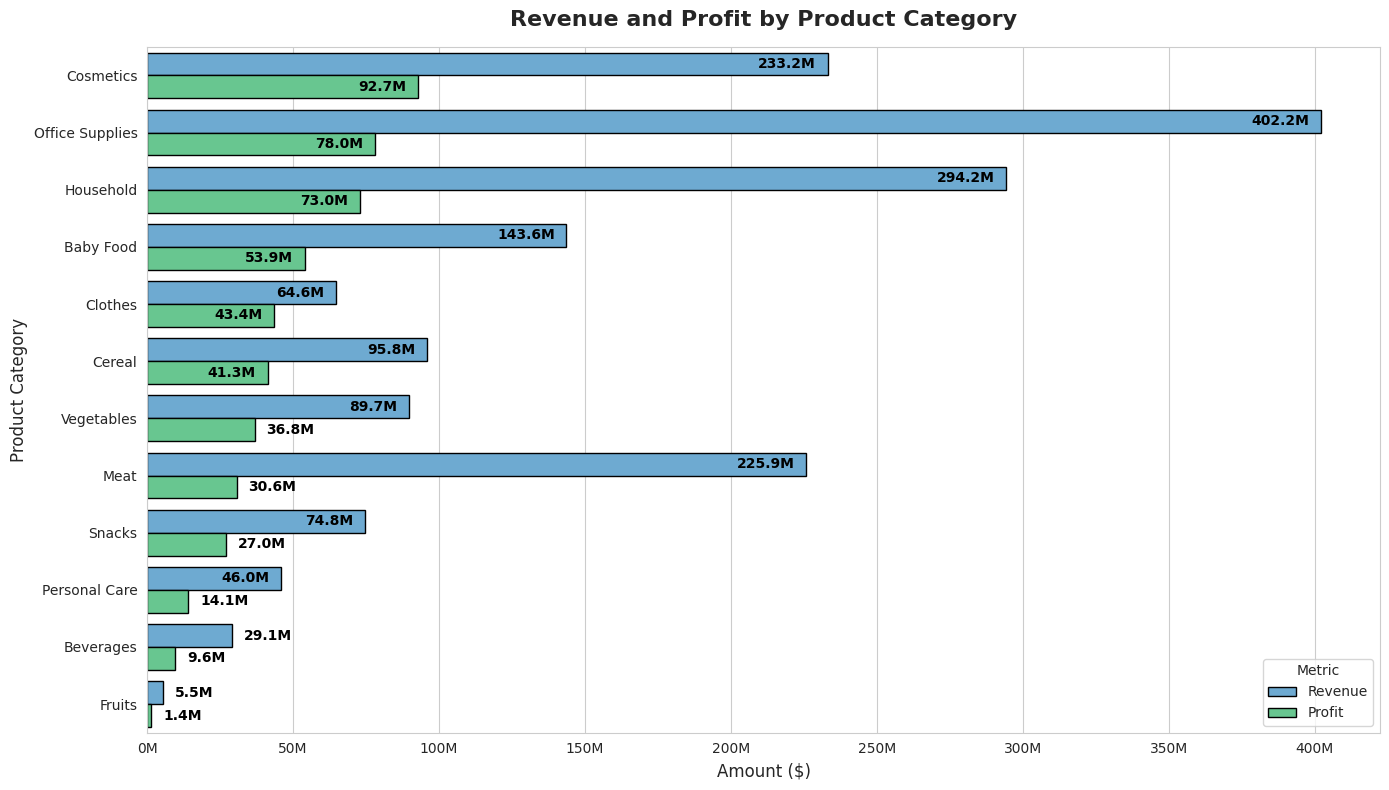

In [ ]:
product_categories_financial_metrics = merged_sales.groupby('Product Category')[['Revenue', 'Profit']].sum().reset_index().sort_values('Profit', ascending=False)

product_categories_financial_data = product_categories_financial_metrics.melt(
    id_vars='Product Category',
    value_vars=['Revenue', 'Profit'],
    var_name='Metric',
    value_name='Amount'
)

fig, ax = plt.subplots(figsize=(14, 8))
plot_revenue_profit_barh_chart(product_categories_financial_data, 'Product Category', ax)

The top-5 categories by profit are `Cosmetics`, `Office Supplies`, `Household`, `Baby Food`, and `Clothes`. There are several categories that stand out among others. `Cosmetics` gathers the largest amount of profit though its revenue is only top-3. `Clothes` category though brings not much of the revenue but is in the top-5 by the amount of profit. `Meat` category is in top-4 by the total revenue, but at the same time brings relatively small profit compared to other categories. `Personal Care`, `Beverages` and `Fruits` bring in the least amount of both revenue and profit.

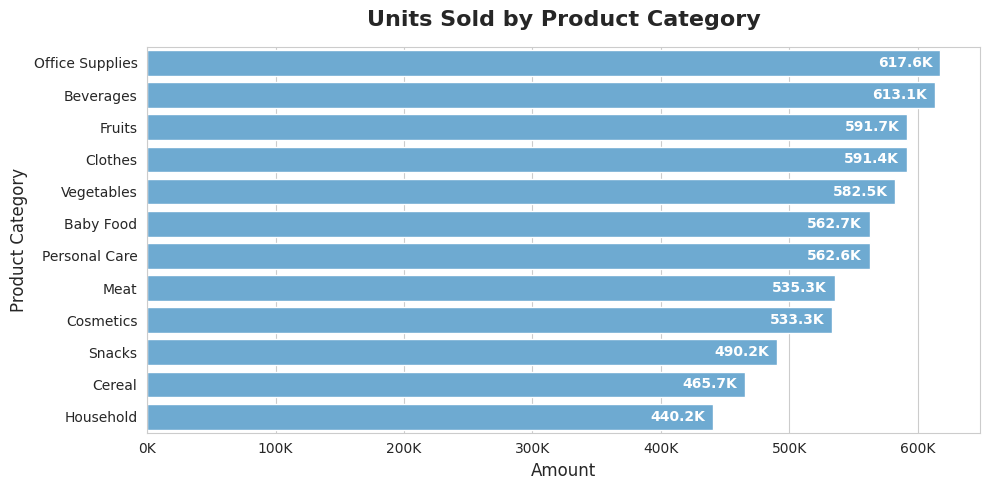

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_data = merged_sales.groupby('Product Category')['Units Sold'].sum().reset_index().sort_values(by='Units Sold', ascending=False)

sns.barplot(data=plot_data, x='Units Sold', y='Product Category', ax=ax, color='#5DADE2')

for container in ax.containers:
    labels = [f"{bar.get_width()/1e3:.1f}K" for bar in container]

    ax.bar_label(
        container,
        labels=labels,
        padding=-45,
        fontsize=10,
        color='white',
        weight='bold'
    )

ax.set_title("Units Sold by Product Category", fontsize=16, pad=15, fontweight="bold")
ax.set_xlabel("Amount", fontsize=12)
ax.set_ylabel("Product Category", fontsize=12)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e3:.0f}K"))

plt.tight_layout()
plt.show()

The distribution of units sold across product categories is relatively balanced, with total sales ranging from 440.2K to 617.6K units. `Office Supplies` is the most popular category, recording 617.6K units sold, closely followed by `Beverages` (613.1K). `Fruits` (591.7K), `Clothes` (591.4K), and `Vegetables` (582.5K) also rank among the top-selling categories.

At the lower end, `Household` products have the fewest units sold (440.2K), followed by `Cereal` (465.7K) and `Snacks` (490.2K). Despite being the least popular, `Household` still accounts for over 440K units sold, suggesting that demand is reasonably distributed across all categories rather than concentrated in only a few products.

####Geography (countries, regions)

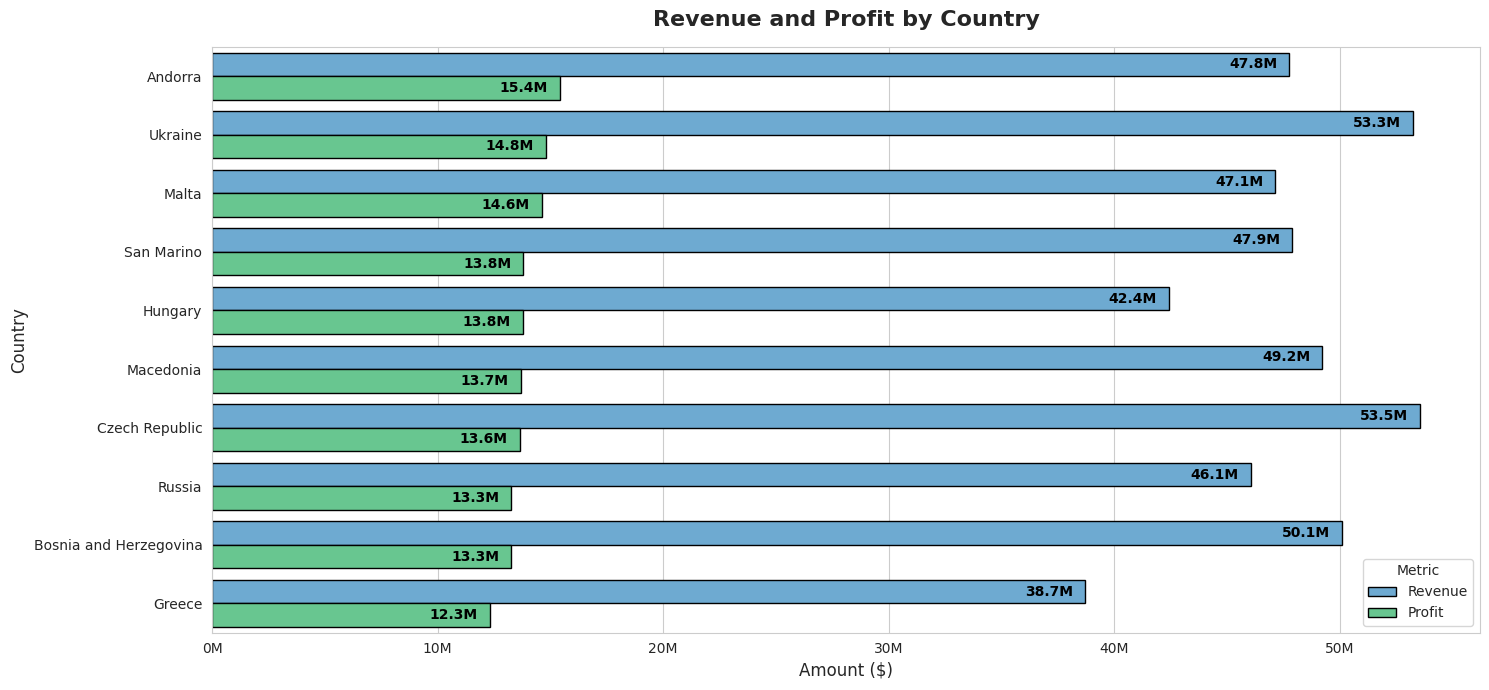

In [ ]:
countries_financial_metrics = merged_sales.groupby('Country')[['Revenue', 'Profit']].sum().reset_index().sort_values('Profit', ascending=False).nlargest(10, columns='Profit')

countries_financial_data = countries_financial_metrics.melt(
    id_vars='Country',
    value_vars=['Revenue', 'Profit'],
    var_name='Metric',
    value_name='Amount'
)

fig, ax = plt.subplots(figsize=(15, 7))

plot_revenue_profit_barh_chart(countries_financial_data, 'Country', ax)

Revenue is consistently much higher than profit across all countries, while the ranking of countries remains broadly similar for both metrics.
The Czech Republic (\$53.5M) and Ukraine (\$53.3M) generate the highest revenues among the displayed countries, closely followed by Bosnia and Herzegovina (\$50.1M) and Macedonia (\$49.2M).
Greece records the lowest revenue (\$38.7M), while Andorra achieves the highest profit (\$15.4M) despite not having the highest revenue.
Profit values are relatively close, ranging from \$12.3M to \$15.4M, compared with a wider revenue range of \$38.7M to \$53.5M. This suggests profitability is more consistent across countries than revenue generation.

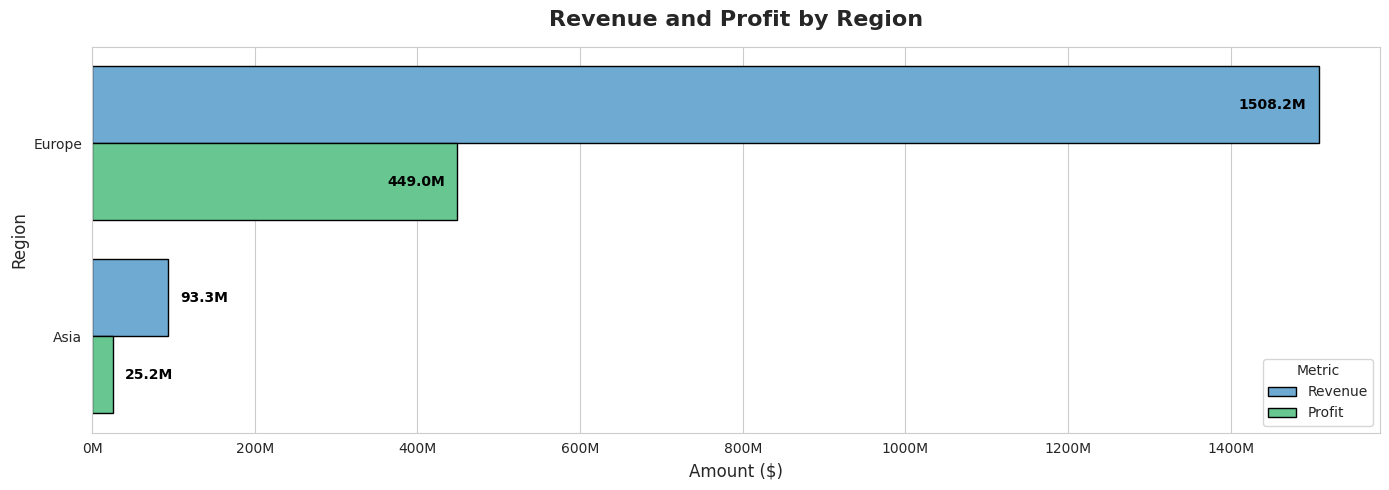

In [ ]:
regions_financial_metrics = merged_sales.groupby('Region')[['Revenue', 'Profit']].sum().reset_index().sort_values('Profit', ascending=False)
regions_financial_data = regions_financial_metrics.melt(
    id_vars='Region',
    value_vars=['Revenue', 'Profit'],
    var_name='Metric',
    value_name='Amount'
)

fig, ax = plt.subplots(figsize=(14, 5))
plot_revenue_profit_barh_chart(regions_financial_data, 'Region', ax)

Europe overwhelmingly dominates financial performance, generating \$1.51B in revenue and \$449.0M in profit, while Asia contributes only \$93.3M in revenue and \$25.2M in profit.
Europe accounts for approximately 94% of total revenue and 95% of total profit, indicating that the business is heavily concentrated in this region.
Although Asia's contribution is relatively small, it remains profitable.
The similar revenue-to-profit relationship across both regions suggests comparable profit margins, despite the significant difference in sales volume.

Europe is the primary revenue and profit driver, whereas Asia represents a much smaller share of overall business activity. This concentration highlights Europe's importance while suggesting potential opportunities to expand sales and market presence in Asia.

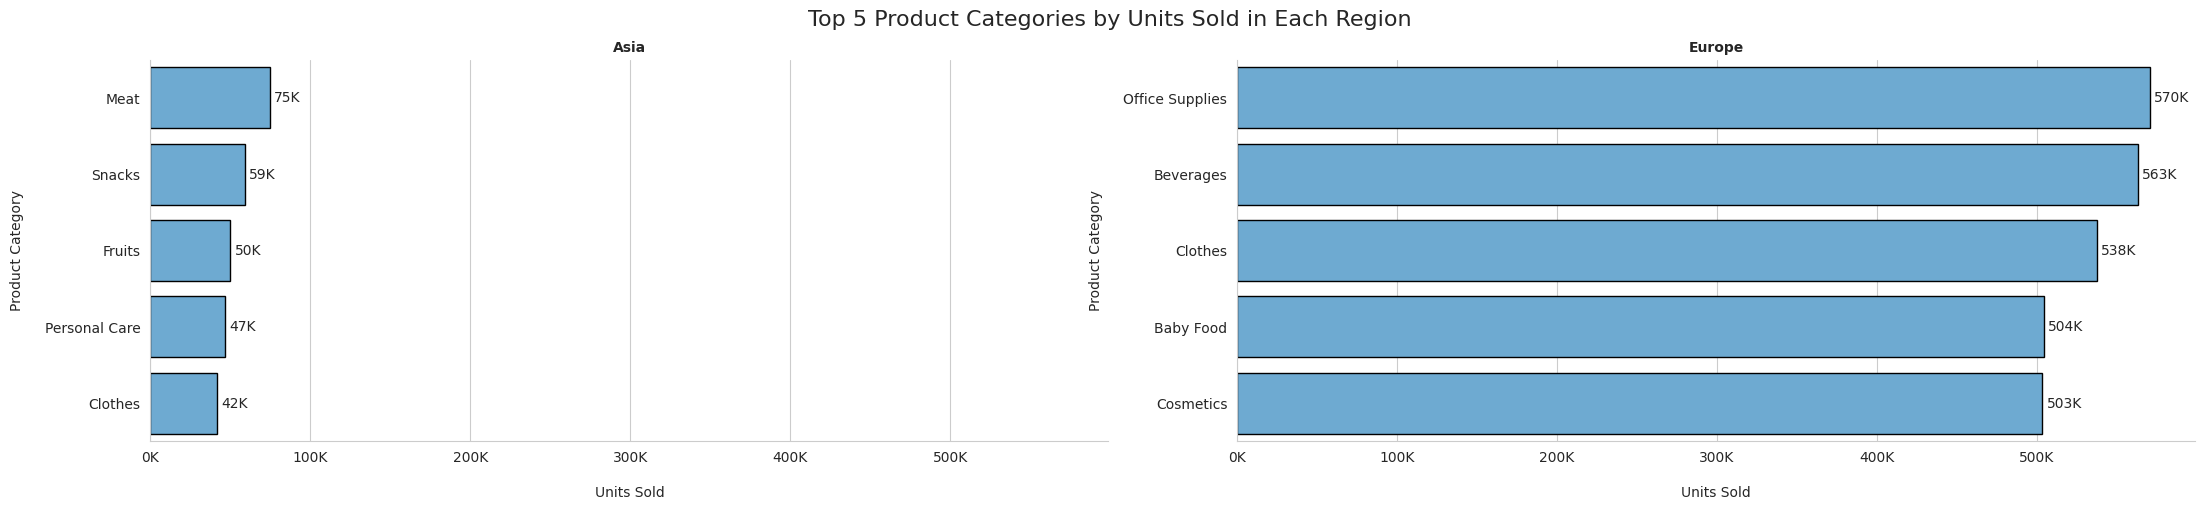

In [ ]:
top5_categories = (
    merged_sales
    .groupby(["Region", "Product Category"])["Units Sold"]
    .sum()
    .reset_index()
    .sort_values(["Region", "Units Sold"], ascending=[True, False])
    .groupby("Region")
    .head(5)
)

g = sns.FacetGrid(
    top5_categories,
    col="Region",
    height=5,
    aspect=2.2,
    sharex=True,
    sharey=False
)

g.map_dataframe(
    sns.barplot,
    x="Units Sold",
    y="Product Category",
    color="#5DADE2",
    edgecolor='black',
)

for ax in g.axes.flat:
    ax.set_xlabel("Units Sold", labelpad=15)
    ax.set_ylabel("Product Category", labelpad=15)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e3:.0f}K"))

    for container in ax.containers:
      labels = [f"{bar.get_width()/1e3:.0f}K" for bar in container]

      ax.bar_label(
          container,
          labels=labels,
          padding=3,
          fontsize=10,
      )

g.set_titles("{col_name}", weight='bold')
g.fig.suptitle("Top 5 Product Categories by Units Sold in Each Region", fontsize=16)
g.fig.subplots_adjust(top=0.88)

The top-selling product categories differ considerably between regions, indicating distinct customer purchasing patterns.
In Europe, Office Supplies (570K units) is the leading category, followed closely by Beverages (563K) and Clothes (538K). The top five categories all exceed 500K units sold, reflecting consistently high demand across multiple product lines.
In Asia, Meat (75K units) ranks first, followed by Snacks (59K), Fruits (50K), Personal Care (47K), and Clothes (42K). Sales volumes are substantially lower than in Europe across all top categories.
Clothes is the only category appearing in the top five for both regions, suggesting broad customer demand regardless of market.
The leading category in Europe (Office Supplies) sells more than seven times as many units as the leading category in Asia (Meat), highlighting the significant difference in market size between the two regions.

Europe accounts for much higher sales volumes and shows strong demand across several product categories. In contrast, Asia has a different product preference profile, with food-related products dominating the rankings. These differences suggest that inventory planning, marketing campaigns, and product assortment should be tailored to the purchasing behavior of each region rather than using a uniform strategy.

####Sales Channels

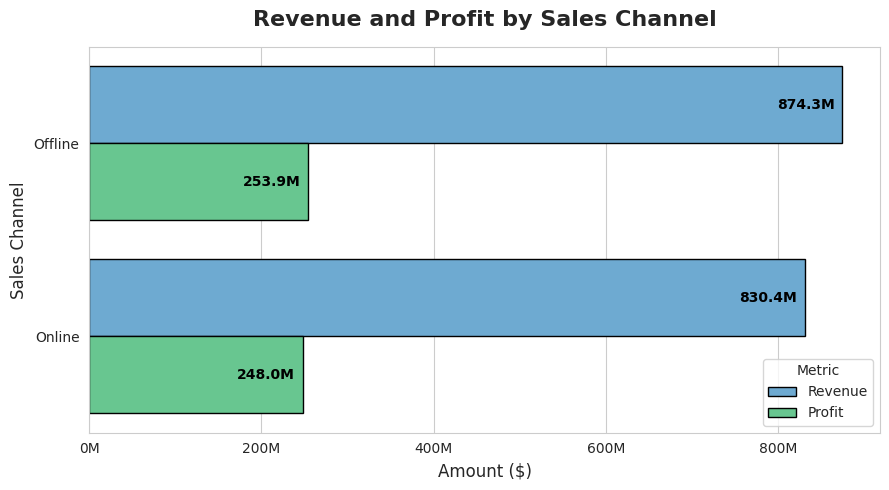

In [ ]:
sales_channel_financial_metrics = merged_sales.groupby('Sales Channel')[['Revenue', 'Profit']].sum().reset_index().sort_values('Profit', ascending=False)
sales_channel_financial_data = sales_channel_financial_metrics.melt(
    id_vars='Sales Channel',
    value_vars=['Revenue', 'Profit'],
    var_name='Metric',
    value_name='Amount'
)

fig, ax = plt.subplots(figsize=(9, 5))
plot_revenue_profit_barh_chart(sales_channel_financial_data, 'Sales Channel', ax)

Offline sales slightly outperform online sales across both key financial metrics. Revenue is \$874.3M for Offline vs \$830.4M for Online, a difference of approximately \$43.9M (5.3%).
Profit follows the same trend, with Offline generating \$253.9M compared to \$248.0M for Online, a modest \$5.9M (2.4%) advantage.
Despite Offline leading, both sales channels contribute almost equally to total revenue and profit. The similar gap in revenue and profit suggests that both channels operate with comparable profitability, with no substantial efficiency advantage for either channel.

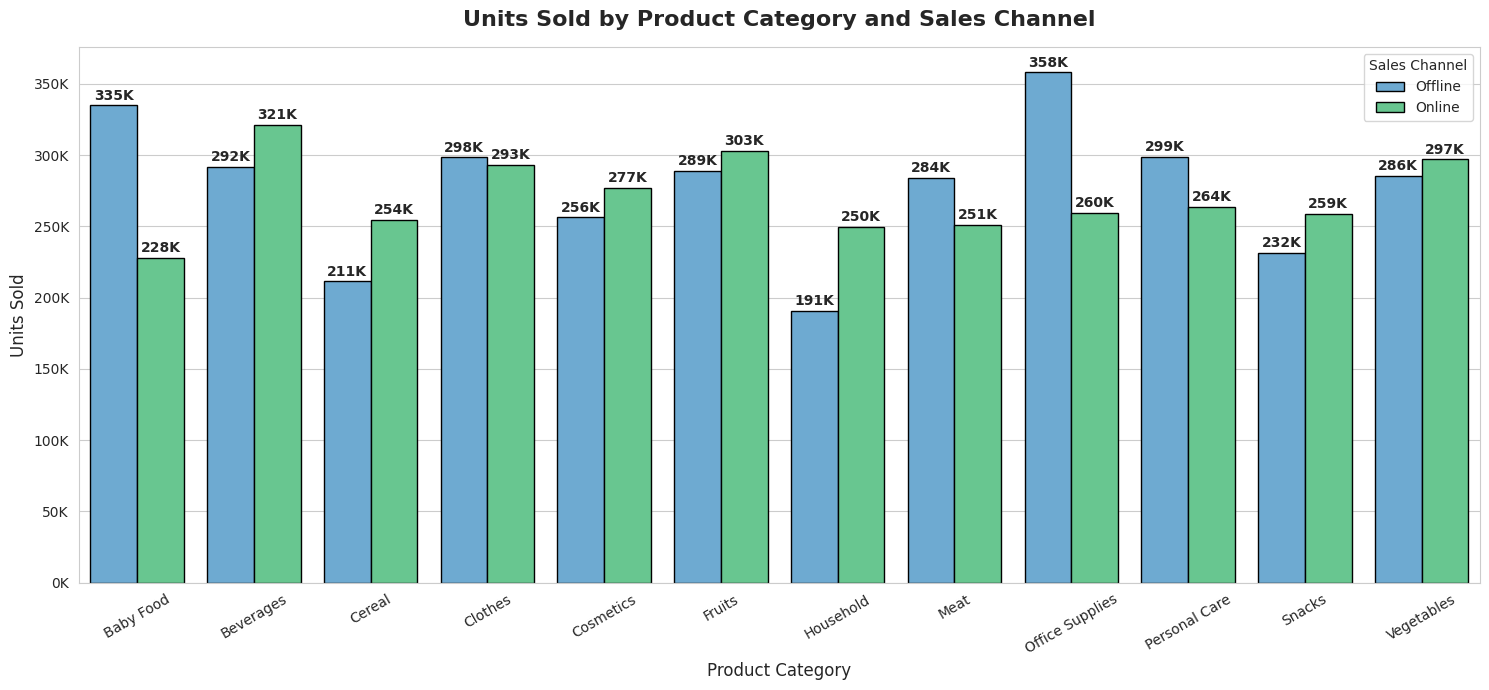

In [ ]:
units_by_category = (
    merged_sales
    .groupby(["Product Category", "Sales Channel"])["Units Sold"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(15, 7))

sns.barplot(
    data=units_by_category,
    x="Product Category",
    y="Units Sold",
    hue="Sales Channel",
    ax=ax,
    edgecolor='black',
    palette=["#5DADE2", "#58D68D12"],
)

ax.set_title("Units Sold by Product Category and Sales Channel", fontsize=16, pad=15, weight='bold')
ax.set_xlabel("Product Category", fontsize=12)
ax.set_ylabel("Units Sold", fontsize=12)
ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e3:.0f}K"))

for container in ax.containers:
    labels = [f"{bar.get_height()/1e3:.0f}K" for bar in container]

    ax.bar_label(
        container,
        labels=labels,
        padding=2,
        fontsize=10,
        weight='bold'
    )

plt.tight_layout()
plt.show()

Sales channel performance varies by product category, with neither Offline nor Online consistently dominating across all categories.

Offline sales lead in `Baby Food`, `Clothes`, `Meat`, `Office Supplies`, and `Personal Care`, with `Office Supplies` recording the highest offline volume (358K units).

Online sales outperform Offline in `Beverages`, `Cereal`, `Cosmetics`, `Fruits`, `Household`, `Snacks`, and `Vegetables`, with `Beverages` achieving the highest online sales (321K units).

`Clothes` exhibits the most balanced channel distribution, with nearly identical unit sales (298K Offline vs. 293K Online).

The largest channel preferences are observed for:  
`Baby Food`, where Offline exceeds Online by 107K units.  
`Office Supplies`, where Offline sells 98K more units than Online.  
`Household`, where Online exceeds Offline by 59K units.  
`Cereal`, where Online outsells Offline by 43K units.  

Most remaining categories show relatively modest differences, suggesting that customers use both channels.

###3.4 Analyze the time interval between ordering and shipping and create relevant visualizations by:
  - Product categories;
  - Countries;
  - Regions.

We'll add a new column `Shipping Time in Days` that will hold a number of days that the shipment took for the order.

In [ ]:
merged_sales['Shipping Time in Days'] = (merged_sales['Ship Date'] - merged_sales['Order Date']).dt.days
merged_sales

,Order Id,Order Date,Ship Date,Order Priority,Country Code,Product Id,Sales Channel,Units Sold,Unit Price,Unit Cost,Product Category,Country,Region,Sub-Region,Revenue,Profit,Shipping Time in Days
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.00,205.70,117.11,Cereal,Norway,Europe,Northern Europe,"133,705.00","57,583.50",10
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,"1,993.00",205.70,117.11,Cereal,Serbia,Europe,Southern Europe,"409,960.10","176,559.87",0
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,"4,693.00",668.27,502.54,Household,NaN,NaN,NaN,"3,136,191.11","777,770.89",24
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,"1,171.00",109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,"127,966.88","85,998.24",31
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,"7,648.00",47.45,31.79,Beverages,Serbia,Europe,Southern Europe,"362,897.60","119,767.68",38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1325,994504153,2017-01-10,2017-01-13,M,SWE,4594,Online,"4,734.00",9.33,6.92,Fruits,Sweden,Europe,Northern Europe,"44,168.22","11,408.94",3
1326,994978797,2014-12-05,2015-01-02,H,ITA,1270,Offline,"5,192.00",47.45,31.79,Beverages,Italy,Europe,Southern Europe,"246,360.40","81,306.72",28
1327,996754205,2010-09-20,2010-09-22,L,RUS,7331,Offline,574.00,255.28,159.42,Baby Food,Russia,Europe,Eastern Europe,"146,530.72","55,023.64",2
1328,998043382,2010-06-15,2010-07-03,H,MLT,8293,Online,"2,070.00",437.20,263.33,Cosmetics,Malta,Europe,Southern Europe,"905,004.00","359,910.90",18


In [ ]:
shipping_time_by_product_categories = merged_sales.groupby('Product Category')['Shipping Time in Days'].mean().round(0).sort_values()
shipping_time_by_countries = merged_sales.groupby('Country')['Shipping Time in Days'].mean().round(0).sort_values()
shipping_time_by_regions = merged_sales.groupby('Region')['Shipping Time in Days'].mean().round(0).sort_values()

def plot_shipping_time(ax, shipping_time_by_category, category_name):
  bars = ax.barh(
      shipping_time_by_category.index,
      shipping_time_by_category.values,
      edgecolor='black',
      color='#5DADE2')

  ax.set_title(f'Shipping Time by {category_name}', fontsize=18, weight='bold', pad=15)
  ax.set_xlabel('Average Shipping Time (days)', fontsize=12, labelpad=12)
  ax.set_ylabel(category_name, fontsize=12, labelpad=12)
  ax.spines[['top', 'right']].set_visible(False)
  ax.bar_label(bars, padding=5, weight='bold', fmt='{:,.0f}')

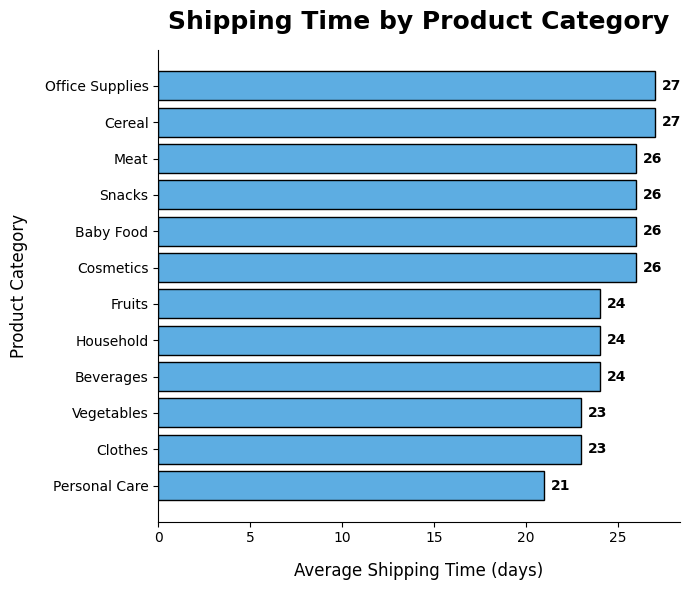

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_shipping_time(ax, shipping_time_by_product_categories, 'Product Category')
plt.tight_layout()
plt.show()

Shipping times are fairly consistent across all product categories, ranging from 21 to 27 days. `Cereal` and `Office Supplies` have the longest average shipping time at 27 days.
`Baby Food`, `Cosmetics`, `Meat`, and `Snacks` follow closely with an average of 26 days.
`Personal Care` has the shortest average shipping time at 21 days, making it about 6 days faster than the slowest categories.

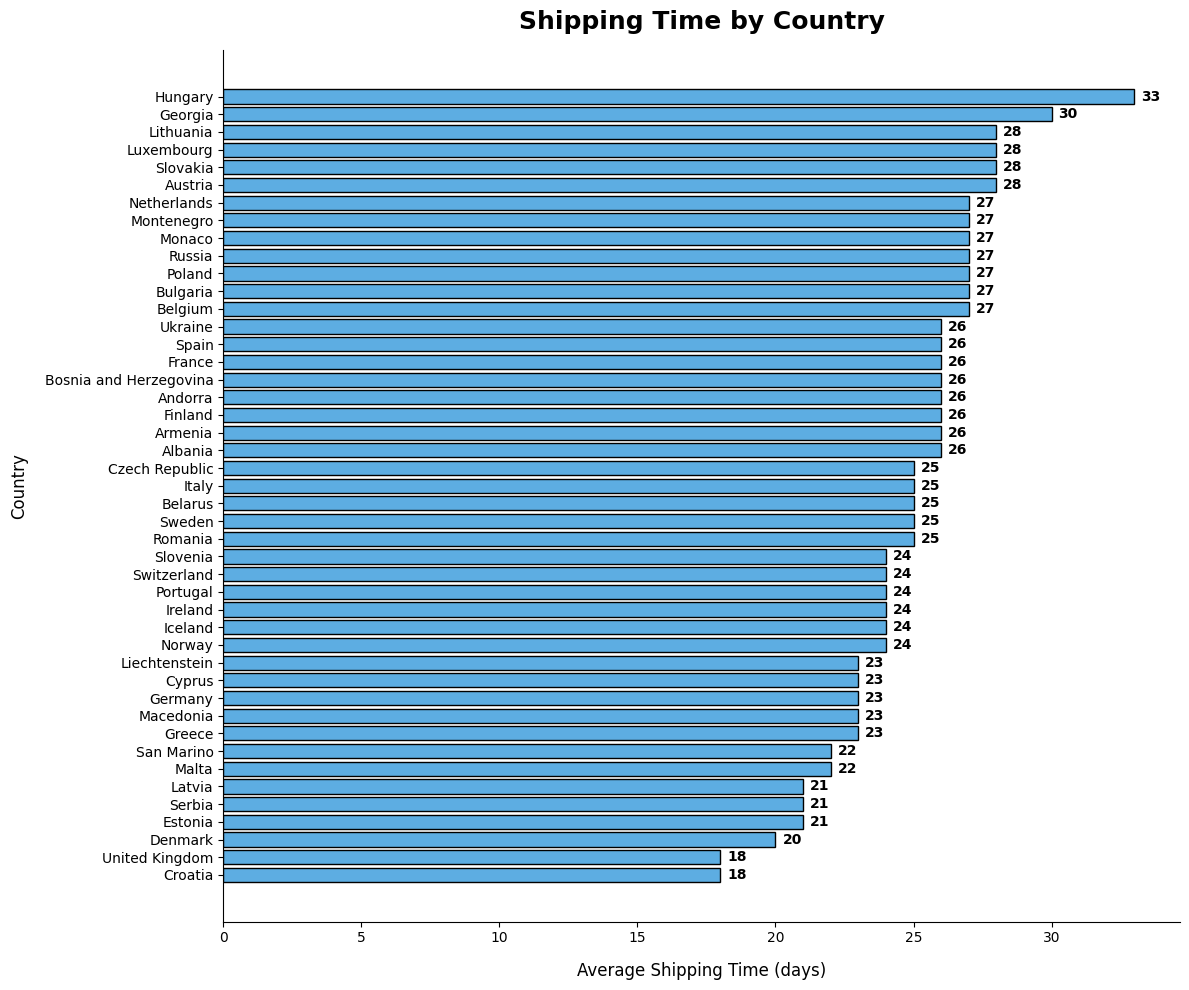

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
plot_shipping_time(ax, shipping_time_by_countries, 'Country')
plt.tight_layout()
plt.show()

Average shipping times range from 18 to 33 days for countries, a spread of 15 days.
Unlike the product category chart (which only varied by 6 days), shipping time varies much more by country, suggesting that geographic or logistical factors have a stronger influence than the type of product. Hungary has the highest average shipping time at 33 days, making it a clear outlier.
Georgia follows with 30 days. United Kingdom and Croatia have the shortest average shipping times, both at 18 days.
Denmark follows with 20 days. Most countries cluster between 23 and 27 days, indicating that while a few countries are notably faster or slower, the majority have similar shipping performance.
Only a handful of countries lie at the extremes (18–21 days or 30–33 days).

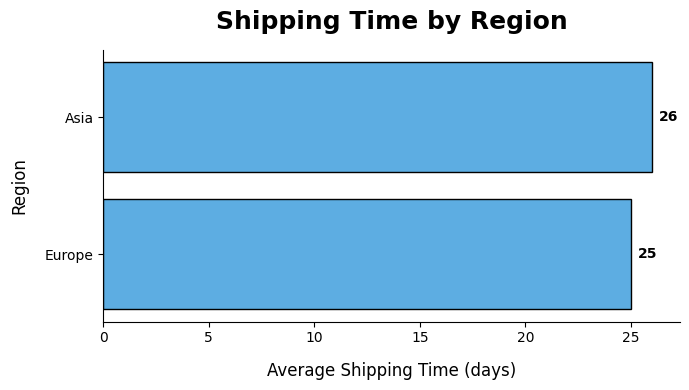

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_shipping_time(ax, shipping_time_by_regions, 'Region')
plt.tight_layout()
plt.show()

The average shipping times are very similar for regions: Asia - 26 days, Europe - 25 days.
The difference is only 1 day, indicating that region has minimal impact on shipping time. Since the regional averages differ by only one day, shipping performance appears to be consistent across regions.
This suggests that the company's logistics network operates with similar efficiency in both Europe and Asia.
The larger differences observed in the country-level analysis indicate that shipping performance is influenced more by individual countries than by the broader region or product category.

###3.5 Analyze whether profit depends on the time required for shipping. Perform the necessary aggregations and visualizations.

Correlation coefficient: 0.06



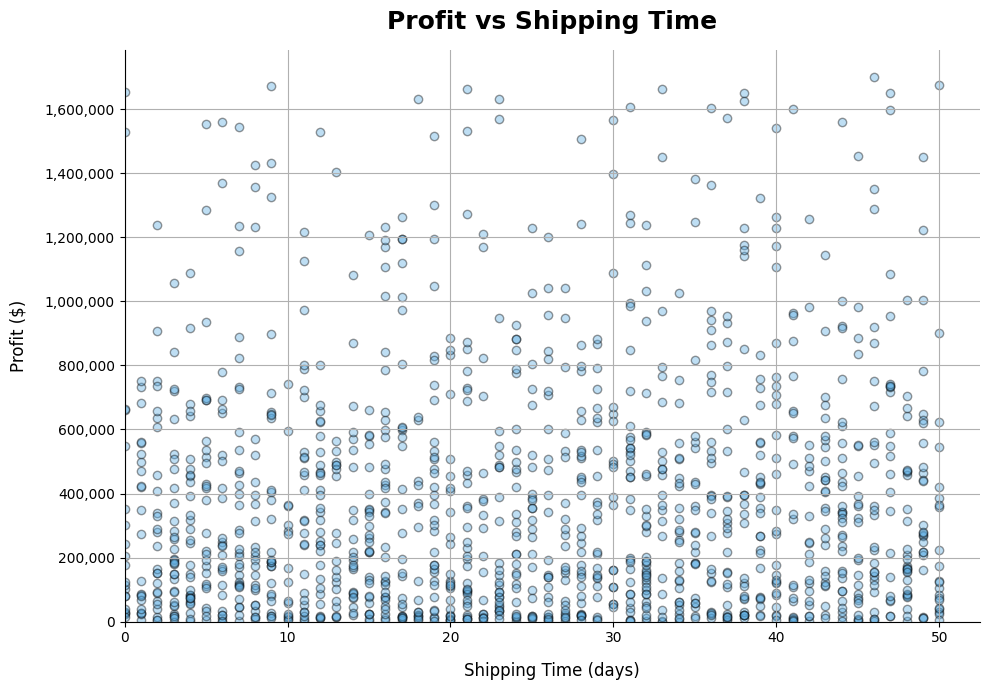

In [ ]:
print(f'Correlation coefficient: {merged_sales['Shipping Time in Days'].corr(merged_sales['Profit']).round(2)}')
print()

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(merged_sales['Shipping Time in Days'], merged_sales['Profit'], alpha=0.4, edgecolor='black', color='#5DADE2')
ax.set_title('Profit vs Shipping Time', fontsize=18, weight='bold', pad=15)
ax.set_xlabel('Shipping Time (days)', fontsize=12, labelpad=12)
ax.set_ylabel('Profit ($)', fontsize=12, labelpad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()


From the chart we see that there is no clear relationship between shipping time and profit (correlation coefficient = 0.06), indicating that shipping time alone is not a strong predictor of profit.
Profits are widely scattered across all shipping times, indicating that orders with both short and long shipping times can generate either high or low profits. Shipping times range from 0 to 50 days.
Orders are distributed fairly evenly across this range, with no obvious clustering at a specific shipping time.
High-profit and low-profit orders occur at nearly every shipping duration.

###3.6 Using visualizations, analyze the sales dynamics (over time) by product categories, countries, and regions to identify main trends.

In [ ]:
def plot_revenue_dynamics(revenue_data, by_column, fig_size=(12,7), title=None):
    if title is None:
      title = f"Revenue Dynamics by {by_column}"

    sns.set_style("whitegrid")

    fig, ax = plt.subplots(figsize=fig_size)

    sns.lineplot(
        data=revenue_data,
        x="Order Date",
        y="Revenue",
        hue=by_column,
        ax=ax,
        palette="tab20"
    )

    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel("Order Date", labelpad=15)
    ax.set_ylabel("Revenue", labelpad=15)
    ax.set_ylim(bottom=0)

    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M"))
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

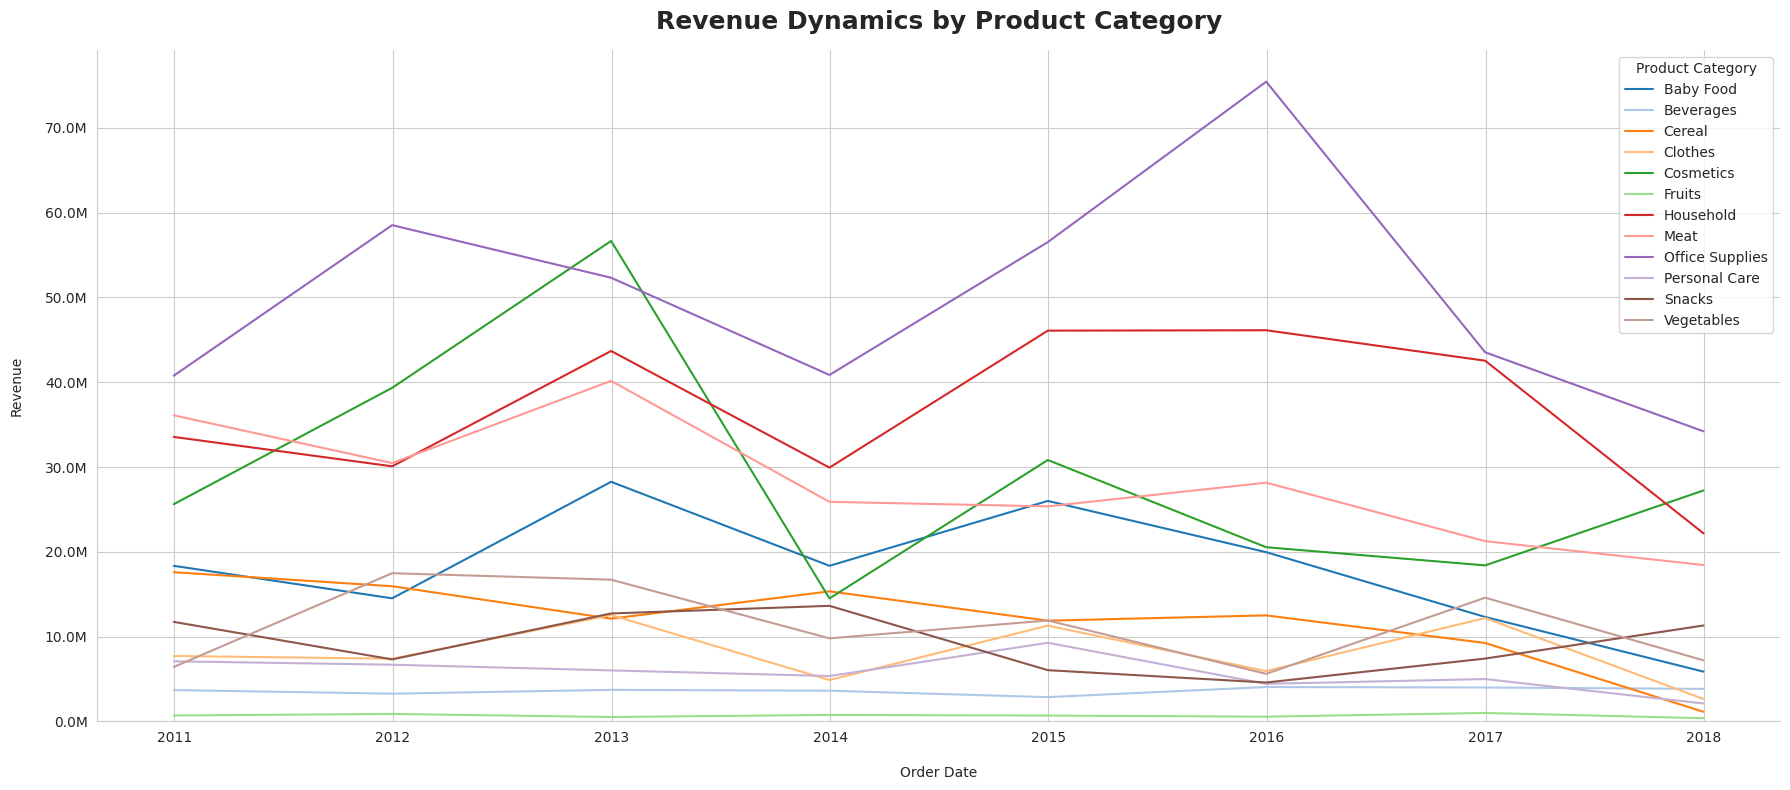

In [ ]:
revenue_by_product_category = (
    merged_sales.groupby([
        pd.Grouper(key="Order Date", freq="YE"),
        "Product Category"
    ])["Revenue"]
    .sum()
    .reset_index()
)

plot_revenue_dynamics(revenue_by_product_category, "Product Category", (18, 8))

**Category-by-category analysis.**

`Office Supplies` generated the highest revenue throughout the period. Revenue increased from ~41M (2011) to a peak of ~76M (2016) (+35M, +85%), before declining to ~34M (2018).  
`Cosmetics` showed the highest volatility. Revenue surged from ~26M (2011) to ~57M (2013) (+31M), dropped sharply to ~15M (2014) (−42M, −74%), then partially recovered to ~27M (2018).  
`Household` remained one of the strongest-performing categories. Revenue rose from ~34M (2011) to ~46M (2015–2016) and then declined to ~22M (2018), still remaining above many other categories.  
`Meat` experienced an overall downward trend despite a temporary peak. Revenue reached ~40M (2013) but steadily decreased afterward to ~18M (2018), a decline of roughly 55% from its peak.  
`Baby Food` fluctuated between ~15M and ~28M. Revenue peaked at ~28M (2013) and ~26M (2015) before falling to its lowest level of ~6M (2018).  
`Cereal` showed a gradual decline over time, decreasing from ~18M (2011) to only ~1M (2018), indicating a substantial reduction in revenue.  
`Clothes` remained relatively low but volatile. Revenue fell from ~17M (2011) to ~5M (2014), rebounded to ~12M (2017), and dropped again to ~2M (2018).  
`Vegetables` maintained relatively stable revenue, fluctuating between ~5M and ~12M, with no strong long-term growth or decline.  
`Personal Care` gradually declined from ~7M (2011) to ~3M (2018), despite a brief increase to around ~9M (2015).  
`Beverages` consistently generated low revenue, remaining between ~3M and ~5M across all years.  
`Snacks` revenue fell from ~11.5M (2011) to ~7M (2012), recovered to a peak of ~12–13M (2014), declined to a low of ~4.5M (2016), and then rebounded to ~11M (2018), ending close to its initial revenue level.  
`Fruits` generated the lowest revenue of all categories throughout the period, remaining below 1M every year with minimal variation.

`Office Supplies` was the primary revenue driver which significantly outperformed all other categories.
`Cosmetics` and `Household` were major contributors but experienced considerable year-to-year volatility.
Several categories (`Cereal`, `Baby Food`, `Meat`) show declining revenue toward the end of the period, which suggests that probably some deeper analysis of the amrket of these categories is needed to understand what could cause such a declining change.
Low-revenue categories such as `Fruits`, `Beverages`, and `Personal Care` contributed relatively little to total revenue and may present opportunities for optimization or portfolio review.

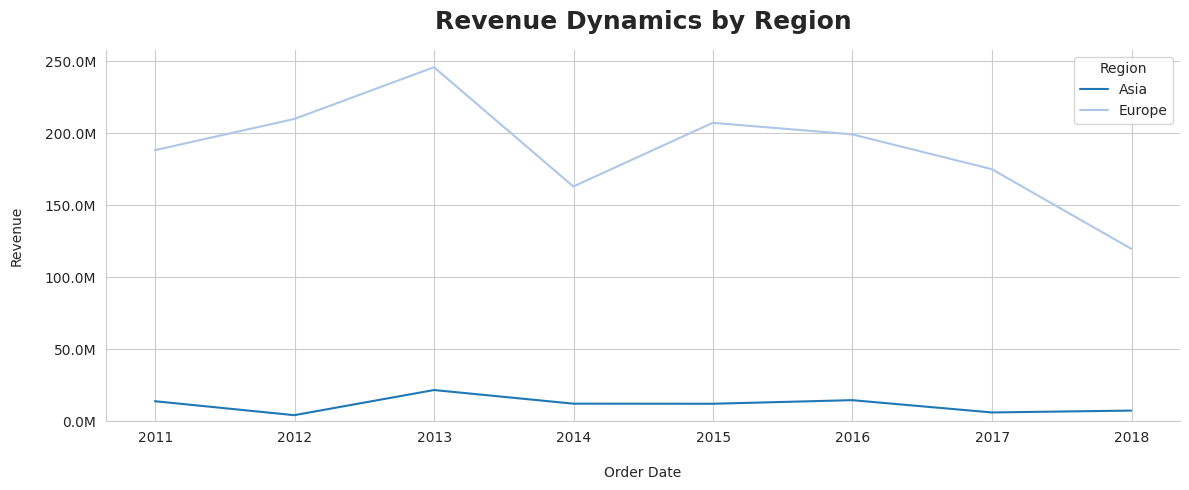

In [ ]:
revenue_by_product_category = (
    merged_sales.groupby([
        pd.Grouper(key="Order Date", freq="YE"),
        "Region"
    ])["Revenue"]
    .sum()
    .reset_index()
)

plot_revenue_dynamics(revenue_by_product_category, "Region", (12, 5))

Europe consistently generated the highest revenue, ranging from ~124M to ~246M, while Asia remained between ~7-8M and ~22M. Europe peaked in 2013 at approximately 246M, then experienced its sharpest decline in 2014, dropping to ~163M (−83M, −34%). Revenue partially recovered to ~207M in 2015 (+44M, +27%), before steadily declining to ~120M by 2018 (−126M, −51% from the 2013 peak). Asia also reached its highest revenue in 2013 at around 22M, increasing from ~7M in 2012 (+15M, +214%). Afterward, revenue stabilized mostly between 12M and 15M, before declining to ~7–8M by 2018, around 65% below its 2013 peak.  

Both regions exhibit a similar turning point in 2013–2014, suggesting a common business or market event that negatively affected revenue across regions.  
The revenue gap remains substantial throughout the period. Even in 2018, Europe generated ~120M versus ~8M in Asia, indicating Europe remained the company's primary revenue driver despite its downward trend.

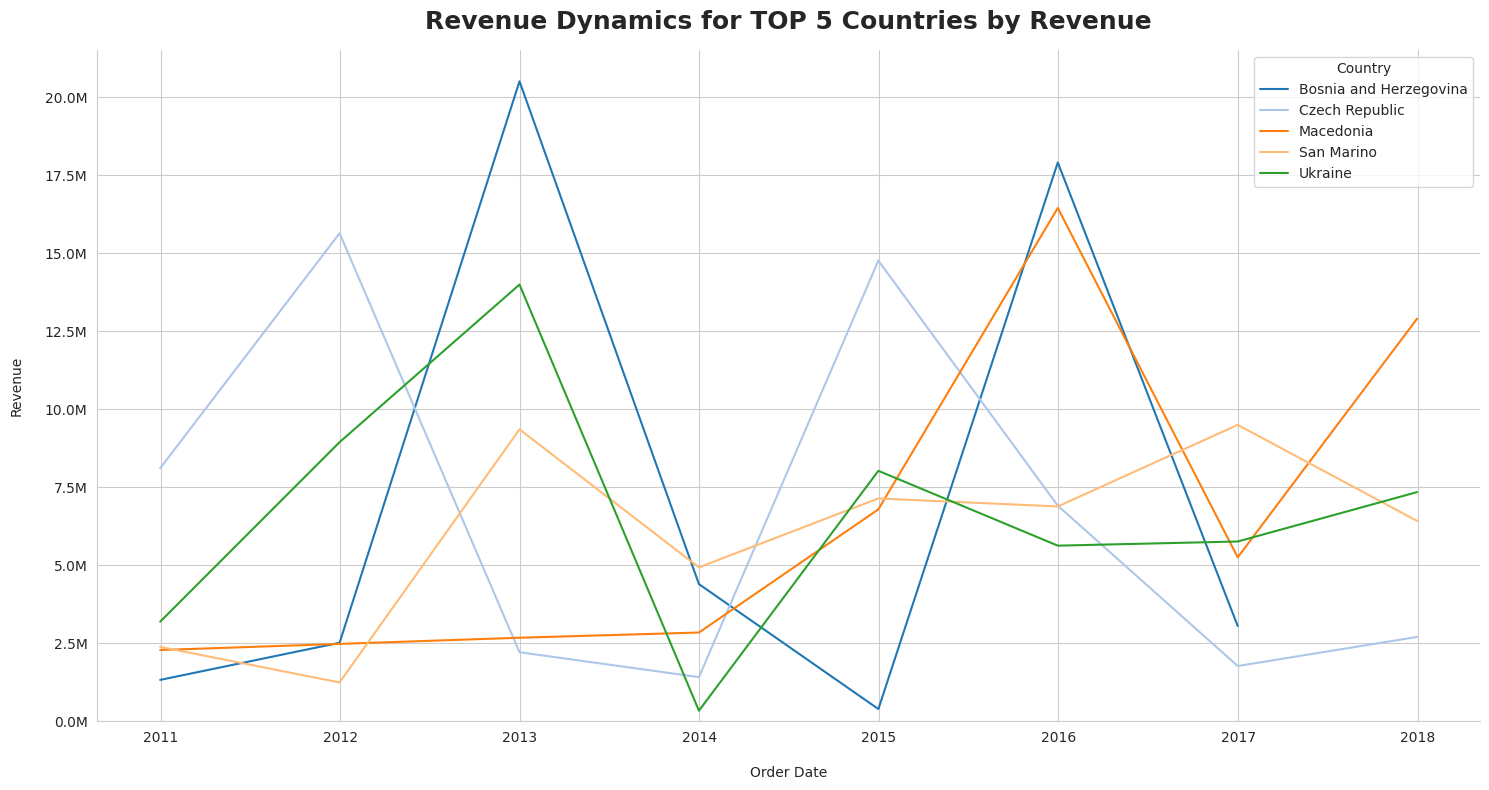

In [ ]:
# Top countries by total revenue
top5_countries = (
    merged_sales
        .groupby("Country")["Revenue"]
        .sum()
        .nlargest(5)
        .index
)

top5_revenue = merged_sales[merged_sales["Country"].isin(top5_countries)]

revenue_by_countries = (
    top5_revenue.groupby([
        pd.Grouper(key="Order Date", freq="YE"),
        "Country"
    ])["Revenue"]
    .sum()
    .reset_index()
)

plot_revenue_dynamics(revenue_by_countries, "Country", (15,8), f"Revenue Dynamics for TOP 5 Countries by Revenue")


`Bosnia and Herzegovina` generated the highest single-year revenue among all countries, peaking at ~20.5M in 2013 and ~17.9M in 2016. However, it also showed the greatest volatility, dropping from 20.5M (2013) to 4.5M (2014) (−78%) and then to 0.4M (2015) (−91%), before recovering sharply in 2016 and falling again in 2017.

`Czech Republic` exhibited a cyclical revenue pattern with two major peaks: ~ 15.6M in 2012 and ~ 14.8M in 2015. Outside these peak years, revenue remained much lower (~1.5–8.1M).

`Macedonia` demonstrated the strongest long-term growth trend. Revenue increased steadily from ~2.3M in 2011 to ~16.4M in 2016, dipped to ~5.3M in 2017, and recovered to ~12.9M in 2018. Unlike the other countries, Macedonia ended the period at a substantially higher revenue level than it started.

`San Marino` maintained relatively stable performance after 2013, with revenue fluctuating mostly between 5.0M and 9.5M. Compared with the other countries, it experienced smaller year-to-year changes and overall showed a moderate growth trend toward the end of the period.

`Ukraine` experienced moderate growth with noticeable fluctuations. Revenue increased from ~3.2M in 2011 to ~14.0M in 2013, fell sharply to ~0.4M in 2014 (−97%), then recovered to ~8.0M in 2015 and stabilized around 5.6–7.4M through 2018.

Revenue leadership changed frequently across years. No country consistently dominated the period: the `Czech Republic` led in 2011, 2012 and 2015, `Bosnia and Herzegovina` in 2013 and 2016, `San Marino` in 2014 and 2017, while `Macedonia` became one of the strongest performers by 2018.

2013 was the strongest year overall, while 2014 marked a widespread downturn, as three of the five countries experienced significant declines.

###3.7 Analyze product sales by days of the week. Can any products be considered seasonal?

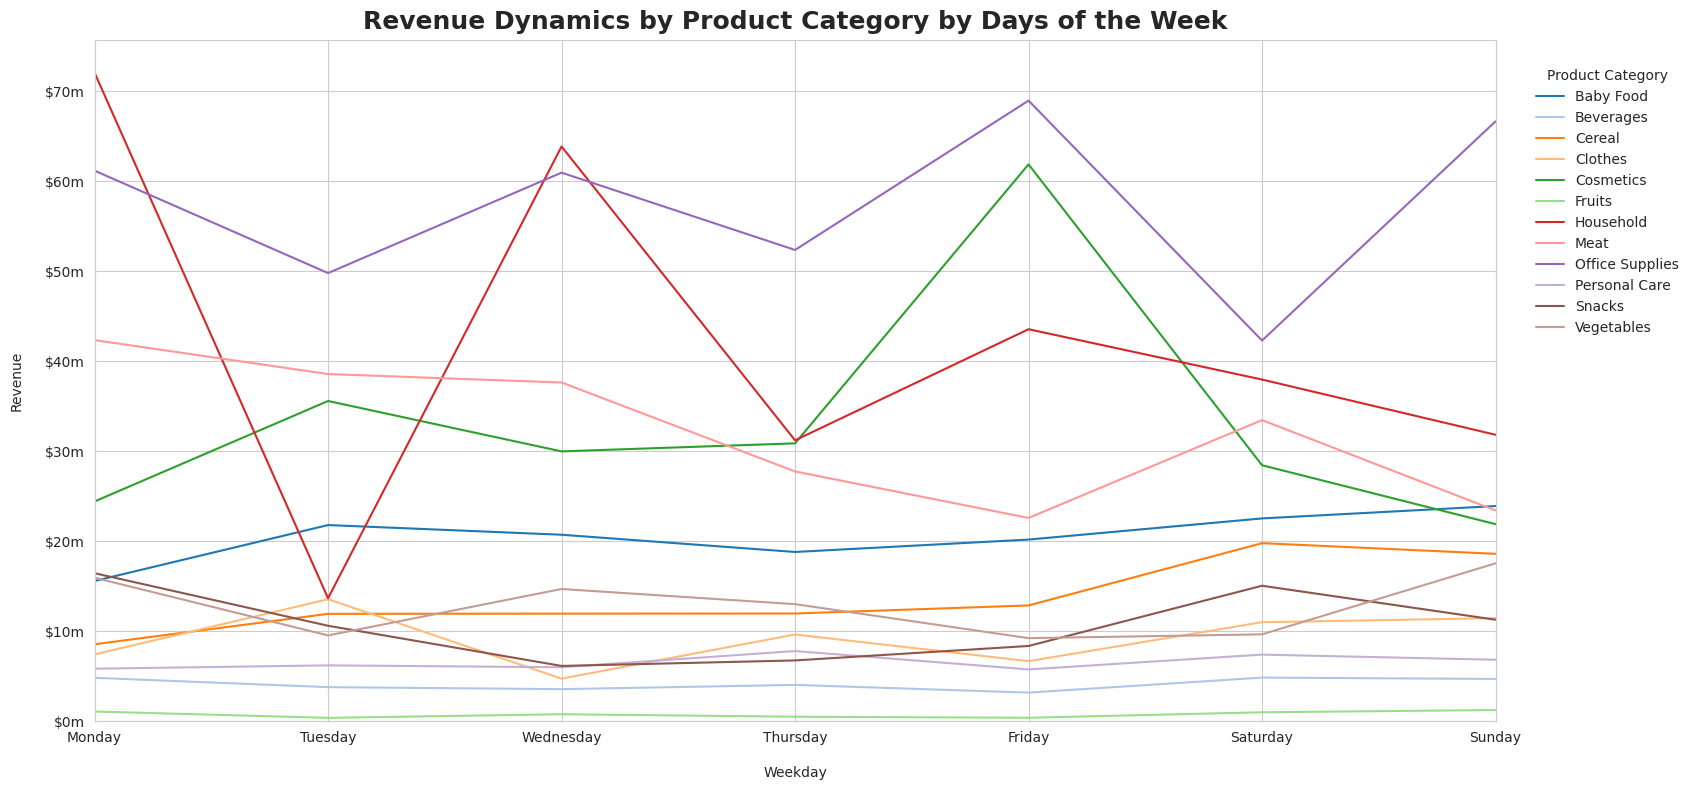

In [ ]:
sns.set_style("whitegrid")

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

merged_sales["Weekday"] = pd.Categorical(
    merged_sales["Order Date"].dt.day_name(),
    categories=weekday_order,
    ordered=True
)

grouped_by_weekday = (
    merged_sales
      .groupby(["Weekday", "Product Category"], observed=True)["Revenue"]
      .sum()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(17,8))

sns.lineplot(
    data=grouped_by_weekday,
    x="Weekday",
    y="Revenue",
    hue="Product Category",
    ax=ax,
    palette="tab20"
)

ax.set_title(
    "Revenue Dynamics by Product Category by Days of the Week",
    fontsize=18,
    fontweight="bold",
    y=1.005
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1_000_000:,.0f}m'))
ax.xaxis.labelpad = 15
ax.yaxis.labelpad = 15
ax.set_ylim(bottom=0)
ax.set_xmargin(0)
ax.legend(
    title="Product Category",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.55),
    frameon=False
)

fig.subplots_adjust(right=0.82)

plt.tight_layout()
plt.show()

Most product categories show relatively stable revenue throughout the week, indicating that customer demand is fairly consistent regardless of the weekday.
Weekday effects are present only for some categories rather than across the entire product range.

`Cosmetics` experience a revenue spike on Friday and sharp decline during the weekend. `Baby Food`, `Cereal`, `Snacks` perform better during the weekend, suggesting increased grocery shopping before or during weekends, whereas `Fruits`, `Beverages`, and `Personal Care` display minimal variation throughout the week. `Clothes` has highest sales on Tuesday, then noticeable dip on Wednesday, weekend sales recover but do not exceed Tuesday. `Household` is extremely volatile across the week, has very high Monday and Wednesday sales, Tuesday is unusually low. `Meat` has general downward trend from Monday to Friday, temporary increase on Saturday and then falls again on Sunday. `Office Supplies` maintain consistently high revenue with peaks on Friday and Sunday, has a noticable dip on Saturday. `Vegetables` category has moderate fluctuations throughout the week with lowest sales on Tuesday and Friday and highest revenue on Sunday and Monday.

Overall, the chart reveals weekday purchasing patterns rather than seasonal trends; therefore, no product category can be classified as seasonal based on this analysis alone. Identifying seasonal products would require examining sales over months, quarters, or seasons to detect recurring annual patterns.

##Overall Business Summary

The company demonstrates a healthy and diversified product portfolio, generating revenue across multiple product categories, countries, regions, and both sales channels. However, the analysis also reveals several areas that can be improved and where risks could be addressed.

1. `Office Supplies` is the company's strongest product category.  
Office Supplies generated the highest annual revenue throughout the analyzed period, increasing from approximately \$41M in 2011 to \$76M in 2016 (+85%) before declining together with the overall business in later years.
The category consistently outperformed all others, making it the primary revenue driver.
2. `Europe` is the dominant market which can signal a concentration risk.  
European revenue ranged from approximately \$120M to \$246M annually, several times higher than Asia region.
Europe reached its peak at ~\$246M in 2013, but revenue then declined by 51%, reaching approximately \$120M in 2018.
Heavy dependence on one region exposes the company to regional economic and competitive risks. To mitigate this, it's recommended to expand sales efforts into the Asia market.
3. `Sales channels` are well balanced.  
Online and Offline channels contribute similar revenue levels, which indicates an effective cross-channel strategy. Revenue is \$874.3M for Offline vs \$830.4M for Online, a difference of approximately \$43.9M (5.3%). Profit follows the same trend, with Offline generating \$253.9M compared to \$248.0M for Online, a modest \$5.9M (2.4%) advantage. The similar gap in revenue and profit suggests that both channels operate with comparable profitability, with no substantial efficiency advantage for either channel.
4. `Revenue` growth peaked around 2013–2016 before slowing considerably.  
Revenue growth accelerated across most product categories until 2013–2016, after which a broad decline became evident. Office Supplies peaked at approximately \$76M in 2016 before falling to around $41M by 2018 (-46%). Household declined from roughly \$68M to \$38M (-44%), while Cosmetics experienced the sharpest downfall, dropping from approximately \$57M to \$15M (-74%). Similar downward trends were observed across other categories, indicating that the slowdown was company-wide rather than isolated to a few products, suggesting the influence of broader market conditions rather than category-specific issues.
5. `Product performance` differs substantially across categories.  
Product performance is highly uneven. Office Supplies consistently generated the highest revenue, peaking at approximately \$76M in 2016 after growing by 85% from around \$41M in 2011. Household was another strong performer, reaching roughly \$68M at its peak and maintaining relatively stable revenue over time. In contrast, Fruits remained among the weakest categories throughout the analysis, with annual revenue generally below \$25M, less than one-third of Office Supplies at its peak. Cosmetics exhibited the greatest volatility, increasing from approximately \$26M to \$57M (+119%) before declining to around \$15M (-74%) within two years. These large differences in both revenue levels and growth patterns indicate that the company's performance is driven by a small number of consistently strong categories, while several others contribute comparatively little or experience substantial fluctuations.
6. Operational performance is stable.  
Shipping time varies between 0 and 50 days, but its relationship with profitability is negligible (Pearson correlation = 0.06).
This indicates that longer delivery times are not currently reducing profit, suggesting pricing, or market demand have a much stronger influence on profitability.

##Recommendations
1. Continue investing in the highest-return categories.  
Office Supplies and Household consistently generate the strongest revenue and should receive priority in inventory allocation and marketing investment.
2. Reduce regional concentration risk.  
With Europe contributing the majority of company revenue, management should accelerate expansion in  Asia to diversify revenue sources.
3. Reassess underperforming product categories.  
Categories such as Fruits consistently generate relatively low revenue and should be evaluated for assortment optimization, pricing improvements, or promotional campaigns. Resources may be better allocated towards higher-margin categories.
4. Investigate the post-2016 revenue decline.  
Since revenue decreased across multiple product categories and regions, management should analyze external market conditions, pricing strategy, competitive activity, and customer preferences to identify the root causes  and adjust the strategy.
5. Improve logistics efficiency.  
Though shipping time has almost no relationship with profit, it's worth investigating whether the company can try to optimize other aspects of product transportation and storage (such as improve inventory management, reduce warehousing costs, improve customer support) which could reduce cost and improve customer expirience overall.